# Dimensionality Reduction with PCA
**Module:** `unsupervised.pca`  
**Dataset:** `agriculture.csv`

---
PCA helps us visualize high-dimensional data by collapsing many features into a few "Principal Components." In this notebook, we use it to see if different regions or crop types naturally cluster together.

In [1]:
import sys
import os
sys.path.append(os.path.abspath("../../../"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from src.my_ml_package.unsupervised.pca import PCA

## 1. Data Preparation
We will load the agriculture data and scale it. Scaling is **mandatory** for PCA because it is based on variance; if one feature has a larger scale, PCA will be biased toward it.

In [2]:
df = pd.read_csv('../../../data/agriculture.csv')

# Drop non-numeric and target-related columns for Unsupervised learning
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['Year'], errors='ignore')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_df)

print(f"Original features: {numeric_df.columns.tolist()}")

Original features: ['Average_Temperature_C', 'Total_Precipitation_mm', 'CO2_Emissions_MT', 'Crop_Yield_MT_per_HA', 'Extreme_Weather_Events', 'Irrigation_Access_%', 'Pesticide_Use_KG_per_HA', 'Fertilizer_Use_KG_per_HA', 'Soil_Health_Index', 'Economic_Impact_Million_USD']


In [3]:
# Reduce from 8+ features down to 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for the results
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['Crop_Type'] = df['Crop_Type']

print(f"Explained Variance Ratio: {pca.variance_ratio}")

Explained Variance Ratio: [0.18639437 0.10492919]


## 2. Visualizing the Clusters
Now we plot the 2D projection. If the points cluster by `Crop_Type`, it means those crops have distinct environmental profiles.

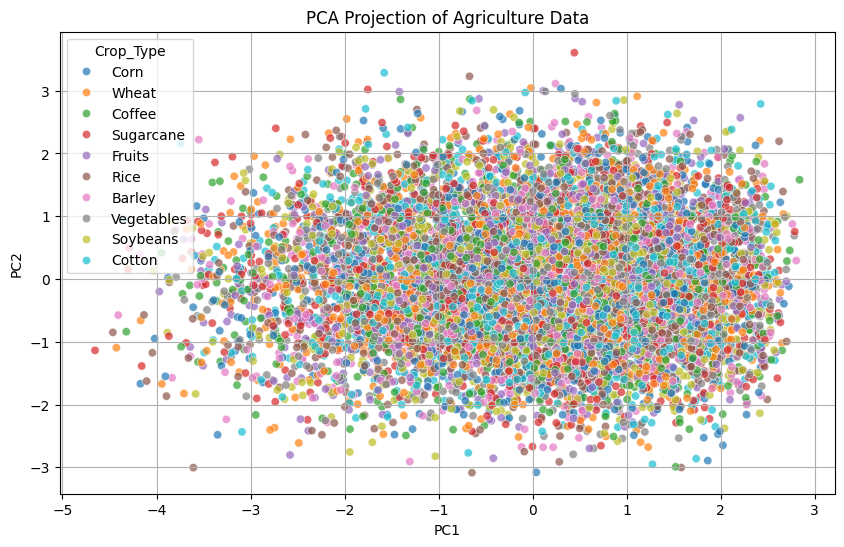

In [4]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Crop_Type', alpha=0.7)
plt.title("PCA Projection of Agriculture Data")
plt.grid(True)
plt.show()

## Conclusion
- PCA reduced our feature space to two components while retaining a specific percentage of the total variance.
- This allows us to see relationships between features that are normally impossible to visualize in high-dimensional space.